In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker

In [86]:
#这里dir1是pre_131.sav的目录对应0-31，dir2是131.sav的目录对应32-132，exptime是长148的观测时间
def aia_intensity_curve(dir1,dir2,dir3,exptime,wavelenth):
    from scipy.io import readsav
    #这部分先把数据读入进来
    matrices=[]
    data1=readsav(dir1)
    matrix_struct=data1['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    matrices=matrices[69:]#这一步是当时我matrices统一设置成大小为110了，所以存的数据都在后面
    data2=readsav(dir2)
    matrix_struct=data2['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    data3=readsav(dir3)
    matrix_struct=data3['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    #计算平均强度
    intensity=np.zeros(148)
    for i in range(148):
        intensity[i]=np.average(matrices[i])
    #这里去掉曝光时间不一致的点，131和193单独处理
    if wavelenth=='131' or '193':
        threshold=2.90 if wavelenth=='131' else 1.99
        #print(threshold)
        intensity[exptime[:]<threshold]=np.nan
        #把去掉的点用插值函数补上
        x=np.arange(148)
        valid_x=x[~np.isnan(intensity)]
        valid_intensity=intensity[~np.isnan(intensity)]
        f=interp1d(valid_x,valid_intensity,kind='linear')
        intensity[np.isnan(intensity)]=f(x[np.isnan(intensity)])
    #归一化
    intensity=(intensity-np.min(intensity))/(np.max(intensity)-np.min(intensity))
    return intensity

In [87]:
intensity=np.zeros((7,148))
name_list=['.94','131','171','193','211','304','335']

for i in range(7):
    file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\\'+name_list[i]+'\*.fits')
    exptime=np.zeros(len(file_list))
    for j in range(len(file_list)):
        rsm=fits.open(file_list[j])
        exptime[j]=rsm[1].header['EXPTIME']

    dir1=r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\pre_'+name_list[i]+'.sav'
    dir2=r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\\'+name_list[i]+'.sav'
    dir3=r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\post_'+name_list[i]+'.sav'
    intensity[i,:]=aia_intensity_curve(dir1,dir2,dir3,exptime[:],name_list[i])
    #print(exptime[:133])

In [88]:
map1=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T210908Z.131.image_lev1.fits')
map2=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211344Z.131.image_lev1.fits')
map3=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211820Z.131.image_lev1.fits')
map4=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T212244Z.131.image_lev1.fits')
map5=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T212620Z.131.image_lev1.fits')
map6=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\171\aia.lev1_euv_12s.2024-06-18T211822Z.171.image_lev1.fits')

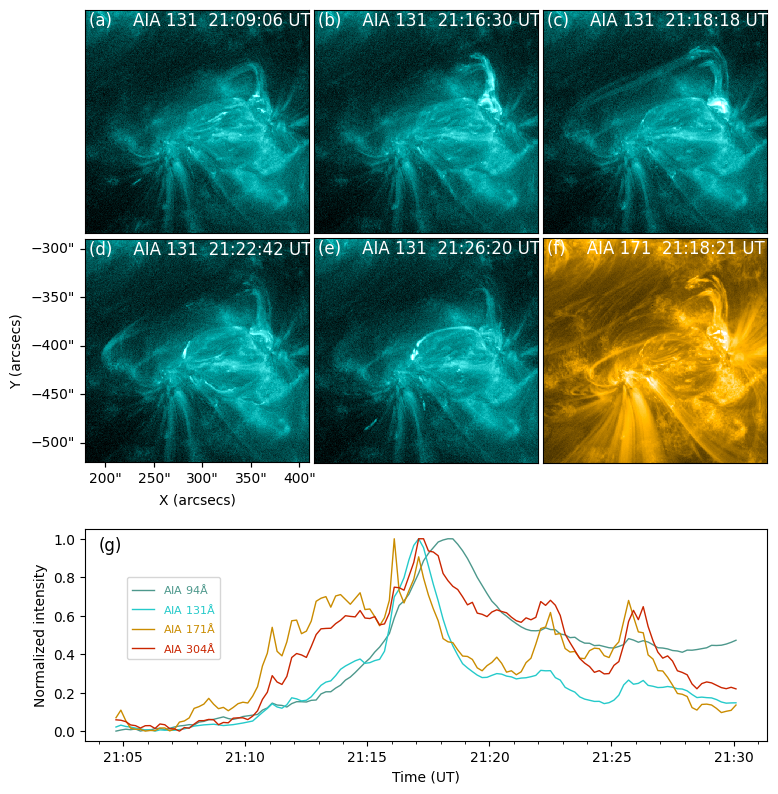

In [95]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8.8,9.5))

# 整体划分为上下两大块：上(3份高度)，下(2份高度)
gs = gridspec.GridSpec(2, 1, height_ratios=[7.5, 3.5], hspace=0.2)

# ---------------- 上半部分：AIA 三幅图 ----------------
# 这里再细分成 1 行 3 列的小网格
gs_top = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=gs[0], wspace=0.02,hspace=0.02)
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)

map_all=[map1,map2,map3,map4,map5,map6]
smap_all=[]
for i in map_all:
    smap_all.append(i.submap(bottom_left,top_right=top_right))

ax_all=[]
for i in range(6):
    ax=fig.add_subplot(gs_top[i],projection=smap_all[i])
    ax_all.append(ax)
    #smap_all[i].plot(axes=ax)
    if i!=5:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=2000
        smap_all[i].plot(axes=ax,norm=old_norm)
    else:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=5000
        smap_all[i].plot(axes=ax,norm=old_norm)
    ax.set_title('')
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    #第四张图加X Y轴
    if i == 3:   # 左下角
        #非常搞，如果不加这个labelpad就会在x轴上方出现一条小缝
        ax.set_xlabel('X (arcsecs)')
        ax.set_ylabel('Y (arcsecs)')
        ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
        ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False)       
    else:
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_ticks_visible(False)
        ax.coords[1].set_ticks_visible(False)

ax_all[0].text(0.02,0.93,'(a)    AIA 131  21:09:06 UT',color='white',transform=ax_all[0].transAxes,fontsize=12)
ax_all[1].text(0.02,0.93,'(b)    AIA 131  21:16:30 UT',color='white',transform=ax_all[1].transAxes,fontsize=12)
ax_all[2].text(0.02,0.93,'(c)    AIA 131  21:18:18 UT',color='white',transform=ax_all[2].transAxes,fontsize=12)
ax_all[3].text(0.02,0.93,'(d)    AIA 131  21:22:42 UT',color='white',transform=ax_all[3].transAxes,fontsize=12)
ax_all[4].text(0.02,0.93,'(e)    AIA 131  21:26:20 UT',color='white',transform=ax_all[4].transAxes,fontsize=12)
ax_all[5].text(0.02,0.93,'(f)    AIA 171  21:18:21 UT',color='white',transform=ax_all[5].transAxes,fontsize=12)

# ---------------- 下半部分：两行共享x轴 ----------------
gs_bottom = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs[1], hspace=0.05)

ax8 = fig.add_subplot(gs_bottom[0])

name_list=['AIA 94$\mathrm{\AA}$','AIA 131$\mathrm{\AA}$',
           'AIA 171$\mathrm{\AA}$','AIA 193$\mathrm{\AA}$',
           'AIA 211$\mathrm{\AA}$','AIA 304$\mathrm{\AA}$','AIA 335$\mathrm{\AA}$']
lines=[]
linstyle=['-','-']

#从AIA那几个波段的cmap里采集颜色用来画曲线
color=[]
color_list=['sdoaia94','sdoaia131','sdoaia171','sdoaia193','sdoaia211','sdoaia304','sdoaia335']
for i in range(7):
    cmap=plt.get_cmap(color_list[i])
    middle_color=cmap(0.55)
    color.append(middle_color)
#画七条AIA曲线
for i in range(7):
    if i==1 or i==2 or i==0 or i==5:
        line,=ax8.plot(intensity[i,20:],color=color[i],label=name_list[i],linewidth=1,linestyle=linstyle[i%2])
        lines.append(line)
legend=ax8.legend(loc='center', bbox_to_anchor=(0.13, 0.58),fontsize=8)
#让legend里的文字颜色和曲线颜色一致
for text,line in zip(legend.get_texts(),lines):
    text.set_color(line.get_color())

corr_x=np.zeros(6)
#第一个时刻对应21：00：42，最后一个时刻对应21：27：06
for i in range(len(corr_x)):
    corr_x[i]=(i*300+18)/12
ax8.set_ylabel('Normalized intensity')
ax8.set_xticks(ticks=corr_x,labels=['21:05','21:10','21:15','21:20','21:25','21:30'])
ax8.text(0.02,0.9,'(g)',color='black',transform=ax8.transAxes,fontsize=12)
import matplotlib.ticker as ticker
ax8.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
ax8.yaxis.set_minor_locator(ticker.NullLocator())       # 禁止 y 轴小刻度
ax8.set_xlabel('Time (UT)')
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig3\aia_image_intensity_curve.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)

IRIS

In [4]:
all_sji_image=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\all_sji_image.sav')['matrix_struct']
data=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_sigma_vel_nonth.npz')
doppler_vel_all=data['doppler_vel_all']
sigma_vel_nonth=data['sigma_vel_nonth']
vel_all2 = np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\vel_all.npy', allow_pickle=True)
vel_all=vel_all2.item()

In [17]:
print(all_sji_image[799][0][330:,:].shape)

(332, 422)


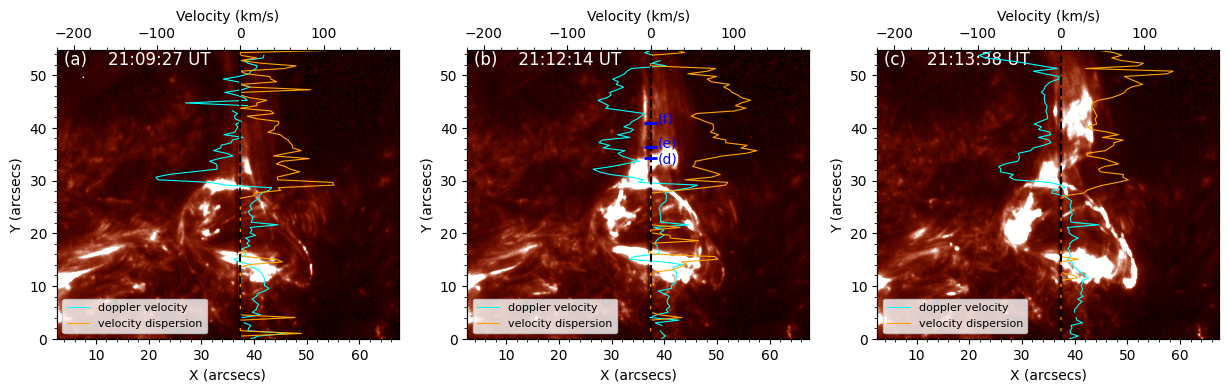

In [9]:
fig=plt.figure(figsize=(15,3.75))
gs=gridspec.GridSpec(1,3,wspace=0.2)
ax_all=[]
for i in range(3):
    ax=fig.add_subplot(gs[i])
    ax_all.append(ax)

list1=[799,807,811]
list2=[399,403,405]
list3=['(a)    21:09:27 UT','(b)    21:12:14 UT','(c)    21:13:38 UT']
for i in range(3):
    ax=ax_all[i]
    ax.imshow(all_sji_image[list1[i]][0][330:,:],cmap='irissji1400',vmin=0,vmax=20,
              origin='lower',extent=[0,422*0.166,0,330*0.166])
    ax.set_xlabel('X (arcsecs)')
    ax.set_ylabel('Y (arcsecs)')
    ax.minorticks_on()
    pos=ax.get_position()
    up_ax=ax.twiny()
    y_vals=np.linspace(0,330*0.166,110)
    kk=list2[i]
    cnt=kk-398
    up_ax.plot(doppler_vel_all[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
    up_ax.plot(sigma_vel_nonth[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
    up_ax.set_xlim(-220,190)
    up_ax.set_xlabel('Velocity (km/s)')
    up_ax.minorticks_on()
    up_ax.axvline(0,color='black',linestyle='--')
    if i==1:
        y_pos=np.array([69,73,82])*0.166*3
        up_ax.hlines(y_pos,-8,8,colors='blue',linewidth=2)
        up_ax.text(8,69*0.166*3-1,'(d)',color='blue',fontsize=10)
        up_ax.text(8,73*0.166*3,'(e)',color='blue',fontsize=10)
        up_ax.text(8,82*0.166*3,'(f)',color='blue',fontsize=10)
    #画双高斯拟合的散点图
    row=np.sum(vel_all[kk*2+1][:,4]==1)
    double_scatter=np.zeros((row,3))
    cnt=0
    ax.text(0.02,0.95,list3[i],color='white',transform=ax.transAxes,fontsize=12)
    up_ax.legend(loc='lower left',fontsize=8)
    #加图标
    
#plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig2\three_iris_all.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)

In [11]:
def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

def double_gaussian(x, a1, x1, sigma1, a2, x2, sigma2,c):
    return (a1 * np.exp(-(x - x1)**2 / (sigma1**2)) +
            a2 * np.exp(-(x - x2)**2 / (sigma2**2)) + c)

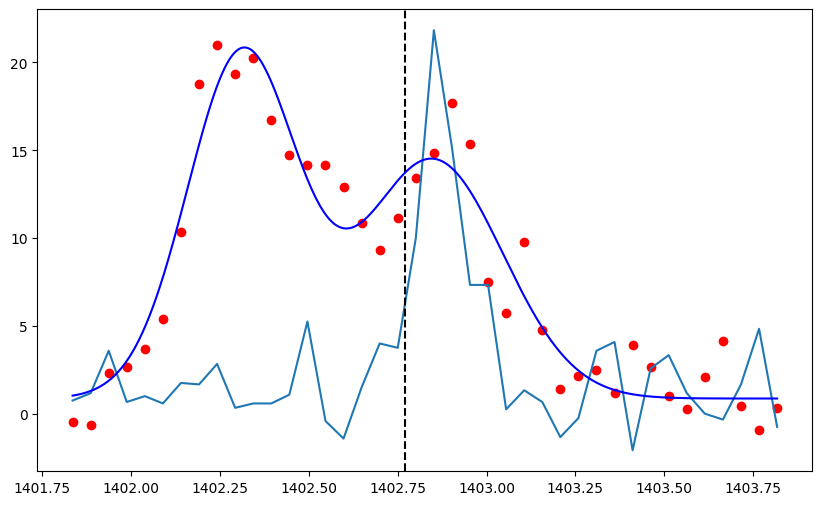

In [ ]:
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[403])
wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
i=73
wave_y=rsm[4].data[4,395+i*3:398+i*3,:].mean(axis=0)
a,b=70,110
x=wave_x[a:b]
y=wave_y[a:b]

j=15
wave_y2=rsm[4].data[4,395+j*3:398+j*3,:].mean(axis=0)
a2,b2=70,110
x2=wave_x[a2:b2]
y2=wave_y2[a2:b2]
#设置初始参数
a1_initial=max(y)-min(y)
sigma1_initial=0.1
x1_initial=1402.3
a2_initial=a1_initial
sigma2_initial=sigma1_initial
x2_initial=1402.77
c_initial=min(y)
initial_guess=[a1_initial,x1_initial,sigma1_initial,
               a2_initial,x2_initial,sigma2_initial,c_initial]

#双高斯拟合
popt,pcov=curve_fit(double_gaussian,x,y,p0=initial_guess,maxfev=5000)
#a1_fit,x1_fit,sigma1_fit,a2_fit,x2_fit,sigma2_fit,c_fit=popt
# 生成拟合曲线
x_fit = np.linspace(min(x), max(x), 1000)
y_fit = double_gaussian(x_fit, *popt)
plt.figure(figsize=(10, 6))
plt.scatter(wave_x[a:b], wave_y[a:b],color='red')
plt.plot(x2,y2)
#plt.grid()
plt.axvline(x=1402.77,color='black',linestyle='--',linewidth=1.5)
plt.plot(x_fit, y_fit, label="Gaussian", color="blue")  # 画拟合曲线

In [3]:
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[403])
i=73
a=rsm[4].data
print(a.shape)

(8, 778, 165)


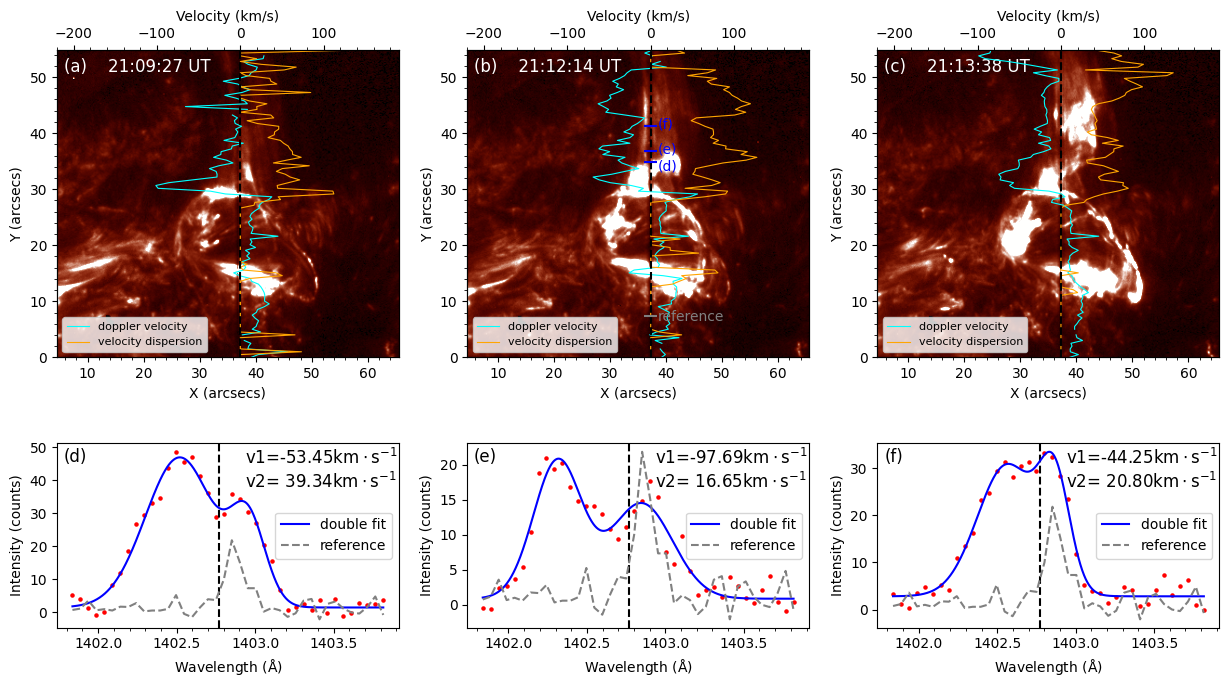

In [ ]:
fig=plt.figure(figsize=(15,7.5))
gs=gridspec.GridSpec(2,1,height_ratios=[5,3],wspace=0.2,hspace=0.35)
gs_top=gridspec.GridSpecFromSubplotSpec(1,3,subplot_spec=gs[0])
ax_all=[]
for i in range(3):
    ax=fig.add_subplot(gs_top[i])
    ax_all.append(ax)

list1=[799,807,811]
list2=[399,403,405]
list3=['(a)    21:09:27 UT','(b)    21:12:14 UT','(c)    21:13:38 UT']
for i in range(3):
    ax=ax_all[i]
    ax.imshow(all_sji_image[list1[i]][0][330:,:],cmap='irissji1400',vmin=0,vmax=20,
              origin='lower',extent=[0,422*0.166,0,330*0.166])
    ax.set_xlabel('X (arcsecs)')
    ax.set_ylabel('Y (arcsecs)')
    ax.minorticks_on()
    pos=ax.get_position()
    up_ax=ax.twiny()
    y_vals=np.linspace(0,330*0.166,110)
    kk=list2[i]
    cnt=kk-398
    up_ax.plot(doppler_vel_all[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
    up_ax.plot(sigma_vel_nonth[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
    up_ax.set_xlim(-220,190)
    up_ax.set_xlabel('Velocity (km/s)')
    up_ax.minorticks_on()
    up_ax.axvline(0,color='black',linestyle='--')
    if i==1:
        y_pos=np.array([69+1,73+1,82+1])*0.166*3#每个是占了三个格点，+1好居中
        up_ax.hlines(y_pos,-8,8,colors='blue',linewidth=1.5)
        up_ax.hlines(15*0.166*3,-8,8,color='gray',linewidth=1.5)
        up_ax.text(8,69*0.166*3-1,'(d)',color='blue',fontsize=10)
        up_ax.text(8,73*0.166*3,'(e)',color='blue',fontsize=10)
        up_ax.text(8,82*0.166*3,'(f)',color='blue',fontsize=10)
        up_ax.text(8,15*0.166*3-1,'reference',color='gray',fontsize=10)
    #画双高斯拟合的散点图
    row=np.sum(vel_all[kk*2+1][:,4]==1)
    double_scatter=np.zeros((row,3))
    cnt=0
    ax.text(0.02,0.93,list3[i],color='white',transform=ax.transAxes,fontsize=12)
    up_ax.legend(loc='lower left',fontsize=8)
    #加图标

#----------------------------------------------------------------------------
gs_bottom=gridspec.GridSpecFromSubplotSpec(1,3,subplot_spec=gs[1])
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[403])
wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
cnt=0
ax2_all=[]
list4=['(d)','(e)','(f)']
for i in [69,73,82]:
    wave_y=rsm[4].data[4,395+i*3:398+i*3,:].mean(axis=0)
    a,b=70,110
    x=wave_x[a:b]
    y=wave_y[a:b]
    j=15
    wave_y2=rsm[4].data[4,395+j*3:398+j*3,:].mean(axis=0)
    a2,b2=70,110
    x2=wave_x[a2:b2]
    y2=wave_y2[a2:b2]
    
    #设置初始参数
    a1_initial=max(y)-min(y)
    sigma1_initial=0.1
    x1_initial=1402.3
    a2_initial=a1_initial
    sigma2_initial=sigma1_initial
    x2_initial=1402.77
    c_initial=min(y)
    initial_guess=[a1_initial,x1_initial,sigma1_initial,
                a2_initial,x2_initial,sigma2_initial,c_initial]

    #双高斯拟合
    popt,pcov=curve_fit(double_gaussian,x,y,p0=initial_guess,maxfev=5000)
    a1_fit,x1_fit,sigma1_fit,a2_fit,x2_fit,sigma2_fit,c_fit=popt

    
    # 生成拟合曲线
    x_fit = np.linspace(min(x), max(x), 1000)
    y_fit = double_gaussian(x_fit, *popt)

    ax=fig.add_subplot(gs_bottom[cnt])
    ax2_all.append(ax)
    ax.scatter(x,y,color='red',s=5)
    ax.axvline(x=1402.77,color='black',linestyle='--',linewidth=1.5)
    ax.plot(x_fit, y_fit, label="double fit", color="blue")  # 画拟合曲线
    ax.plot(x2,y2,color='gray',linestyle='--',label='reference')
    ax.text(0.02,0.9,list4[cnt],color='black',transform=ax.transAxes,fontsize=12)
    ax.set_xlabel('Wavelength $(\mathrm{\AA})$')
    ax.set_ylabel('Intensity (counts)')
    ax.legend(loc='center right')


    v1=(x1_fit-1402.77)/1402.77*299792.458
    v2=(x2_fit-1402.77)/1402.77*299792.458
    ax.text(0.55,0.76,'v1='+f'{v1:.2f}'+'$\mathrm{km \cdot s^{-1}}$\n'+'v2= '+f'{v2:.2f}'+'$\mathrm{km \cdot s^{-1}}$',
            transform=ax.transAxes,fontsize=12)
    
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
    ax.yaxis.set_minor_locator(ticker.NullLocator())    
    cnt=cnt+1


plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig3\iris.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)

DEM 三个不同位置的EM t随时间变化图

In [13]:
time_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\\'+'*.fits')
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\\'+'*.sav')
avg_temp=np.zeros((58,3))
avg_em=np.zeros((58,3))
for i in range(58):
    datas=readsav(file_list[i*2])
    result=datas['result']
    smap_temp=result['SMAP_TEMP'][0]
    smap_em=result['SMAP_EM'][0]

    #avg_temp[i,0]=np.mean(smap_temp[140:150,142:152])
    avg_temp[i,0]=np.mean(smap_temp[145:155,140:150])
    avg_temp[i,1]=np.mean(smap_temp[138:148,102:112])
    avg_temp[i,2]=np.mean(smap_temp[80:90,15:25])
    
    #avg_em[i,0]=np.mean(smap_em[140:150,142:152])
    avg_em[i,0]=np.mean(smap_em[145:155,140:150])
    avg_em[i,1]=np.mean(smap_em[138:148,102:112])
    avg_em[i,2]=np.mean(smap_em[80:90,15:25])


In [14]:
data=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\fit_points.npz')
slice=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix.npy')
a=data['fit_points']
b=data['fit_points2']
c=data['fit_points3']

Text(1, 82, '(3)')

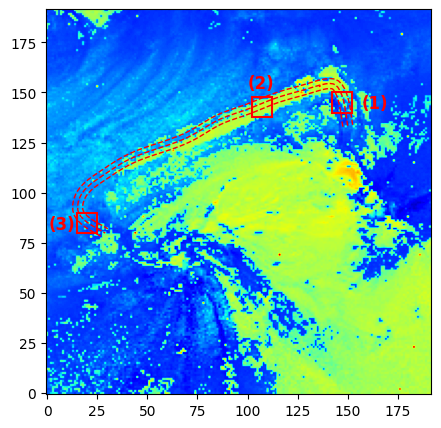

In [43]:
fig,ax22=plt.subplots(figsize=(5,5))
datas=readsav(file_list[56])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
ax22.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')

left_bottom1=(142,140)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax22.plot(b[:,1]/2,b[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.plot(a[:,1]/2,a[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.plot(c[:,1]/2,c[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.add_patch(rect1)

left_bottom2=(102,138)
rect2=Rectangle(left_bottom2,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
left_bottom3=(15,80)
rect3=Rectangle(left_bottom3,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax22.add_patch(rect2)
ax22.add_patch(rect3)

ax22.text(157,142,'(1)',color='red',fontsize=12,fontweight='bold')
ax22.text(100,152,'(2)',color='red',fontsize=12,fontweight='bold')
ax22.text(1,82,'(3)',color='red',fontsize=12,fontweight='bold')

C:\Users\19671\AppData\Local\Temp\ipykernel_10212\1463346929.py:47: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from current font.
  plt.tight_layout()
c:\Users\19671\anaconda3\envs\sun\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


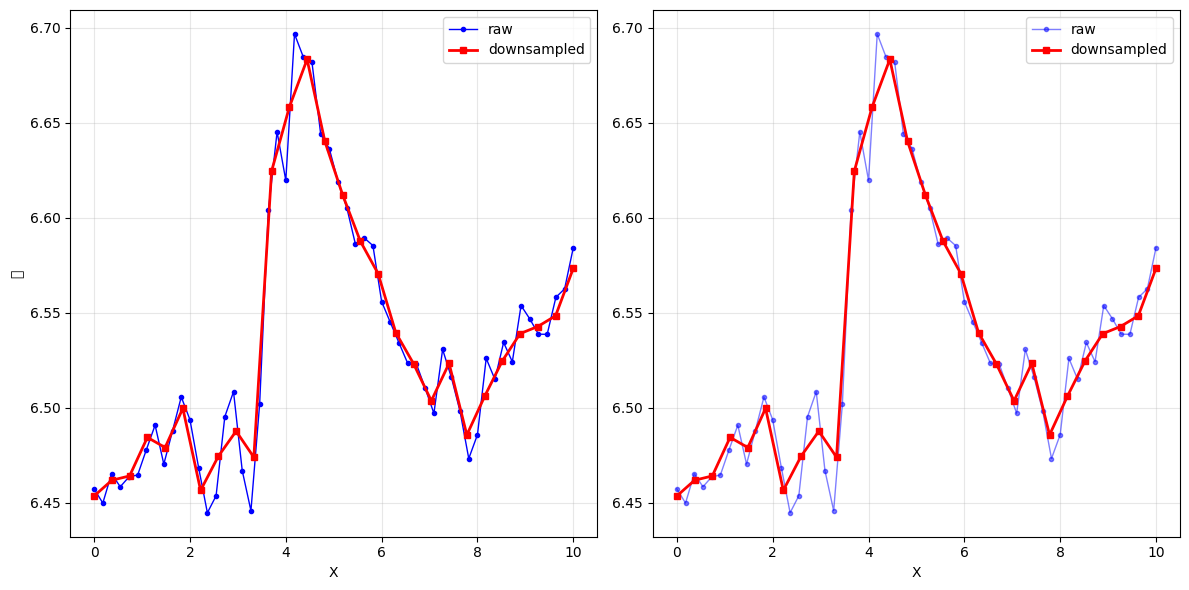

原始数据长度: 56
缩并后数据长度: 28


In [19]:
logT=np.log10(avg_temp)
a=logT[:56,0]
import numpy as np
import matplotlib.pyplot as plt


x_original = np.linspace(0, 10, 56)


# 方法1：简单平均缩并
def downsample_average(data, factor=2):
    """将数据按因子factor缩并（平均）"""
    # 确保数据长度能被缩并因子整除
    new_length = len(data) // factor
    truncated_data = data[:new_length * factor]
    
    # 重塑数组并计算平均值
    downsampled = truncated_data.reshape(new_length, factor).mean(axis=1)
    return downsampled

# 执行缩并
a_downsampled = downsample_average(a)

# 创建新的x坐标（长度减半）
x_downsampled = np.linspace(0, 10, len(a_downsampled))

# 画图对比
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(x_original, a, 'b-o', markersize=3, linewidth=1, label='raw')
plt.plot(x_downsampled, a_downsampled, 'r-s', markersize=4, linewidth=2, label='downsampled')
#plt.title('数据对比')
plt.xlabel('X')
plt.ylabel('值')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x_original, a, 'b-o', markersize=3, linewidth=1, alpha=0.5, label='raw')
plt.plot(x_downsampled, a_downsampled, 'r-s', markersize=5, linewidth=2, label='downsampled')
#plt.title('重叠对比')
plt.xlabel('X')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印信息
print(f"原始数据长度: {len(a)}")
print(f"缩并后数据长度: {len(a_downsampled)}")

In [28]:
print(np.linspace(0,9,10))

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


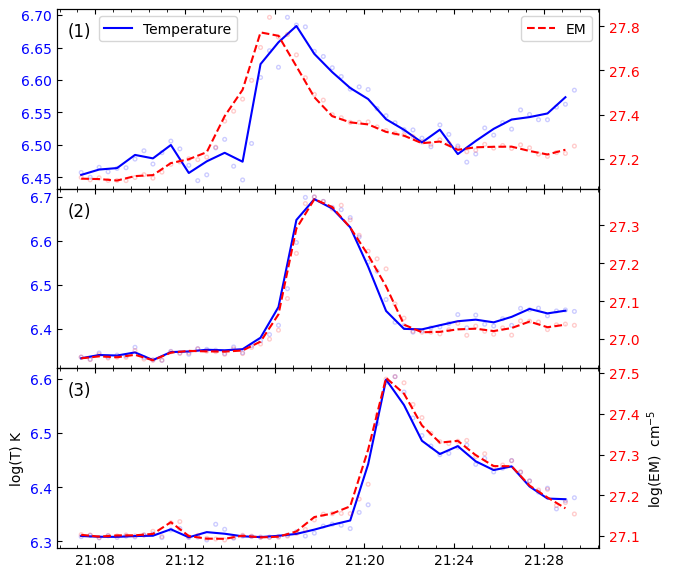

In [38]:
logT=np.log10(avg_temp)
logem=np.log10(avg_em)
xrange=np.linspace(0,54,28)
fig,(ax1,ax2,ax3)=plt.subplots(3,1,figsize=(7,7),sharex=True,
                               gridspec_kw={'height_ratios': [1, 1, 1],'hspace': 0})
data1=logT[:56,0]
downsmaple_data1=data1.reshape(len(data1)//2,2).mean(axis=1)
ax1.plot(xrange,downsmaple_data1,label='Temperature',color='blue')
ax1.scatter(np.linspace(0,55,56),logT[:56,0],alpha=0.2,s=7,facecolor='none',edgecolor='blue')
ax1.tick_params(axis='y',labelcolor='blue')
ax1.text(0.02,0.85,'(1)',color='black',transform=ax1.transAxes,fontsize=12)
ax11=ax1.twinx()
data11=logem[:56,0]
downsmaple_data11=data11.reshape(len(data11)//2,2).mean(axis=1)
ax11.plot(xrange,downsmaple_data11,label='EM',linestyle='--',color='red')
ax11.scatter(np.linspace(0,55,56),logem[:56,0],alpha=0.2,s=7,facecolor='none',edgecolor='red')
ax11.tick_params(axis='y',labelcolor='red')
coor_x=np.zeros(6)
for i in range(len(coor_x)):
    coor_x[i]=(i*240+38)/24
label_x=['21:08','21:12','21:16','21:20','21:24','21:28']
ax1.set_xticks(ticks=coor_x,labels=label_x)
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
ax1.yaxis.set_minor_locator(ticker.NullLocator())
ax1.legend(loc='upper left',bbox_to_anchor=(0.065,1))
ax11.legend(loc='upper right')

data2=logT[:56,1]
downsmaple_data2=data2.reshape(len(data2)//2,2).mean(axis=1)
ax2.plot(xrange,downsmaple_data2,label='Temperature',color='blue')
ax2.scatter(np.linspace(0,55,56),logT[:56,1],alpha=0.2,s=7,facecolor='none',edgecolor='blue')
ax2.tick_params(axis='y',labelcolor='blue')
ax2.text(0.02,0.85,'(2)',color='black',transform=ax2.transAxes,fontsize=12)
ax22=ax2.twinx()
data22=logem[:56,1]
downsmaple_data22=data22.reshape(len(data22)//2,2).mean(axis=1)
ax22.plot(xrange,downsmaple_data22,label='EM',linestyle='--',color='red')
ax22.scatter(np.linspace(0,55,56),logem[:56,1],alpha=0.2,s=7,facecolor='none',edgecolor='red')
#ax22.set_ylabel('EM  '+ r'$10^{27} \text{cm}^3$')
ax22.tick_params(axis='y',labelcolor='red')

data3=logT[:56,2]
downsmaple_data3=data3.reshape(len(data3)//2,2).mean(axis=1)
ax3.plot(xrange,downsmaple_data3,label='Temperature',color='blue')
ax3.scatter(np.linspace(0,55,56),logT[:56,2],alpha=0.2,s=7,facecolor='none',edgecolor='blue')
ax3.set_ylabel('log(T) K')
ax3.tick_params(axis='y',labelcolor='blue')
ax3.text(0.02,0.85,'(3)',color='black',transform=ax3.transAxes,fontsize=12)
ax33=ax3.twinx()
data33=logem[:56,2]
downsmaple_data33=data33.reshape(len(data33)//2,2).mean(axis=1)
ax33.plot(xrange,downsmaple_data33,label='EM 3',linestyle='--',color='red')
ax33.scatter(np.linspace(0,55,56),logem[:56,2],alpha=0.2,s=7,facecolor='none',edgecolor='red')
ax33.set_ylabel('log(EM)  '+ r'$\text{cm}^{-5}$')
ax33.tick_params(axis='y',labelcolor='red')

for ax in [ax1,ax2]:
    ax.label_outer()#去掉上两个的xlabel xticklabel

for ax in [ax1,ax2,ax3]:
    ax.tick_params(axis='x',which='both',direction='in',top='True')
    ax.tick_params(axis='y',which='both',direction='in')
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig3\T_DEM_time2.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)


这个是没取对数的

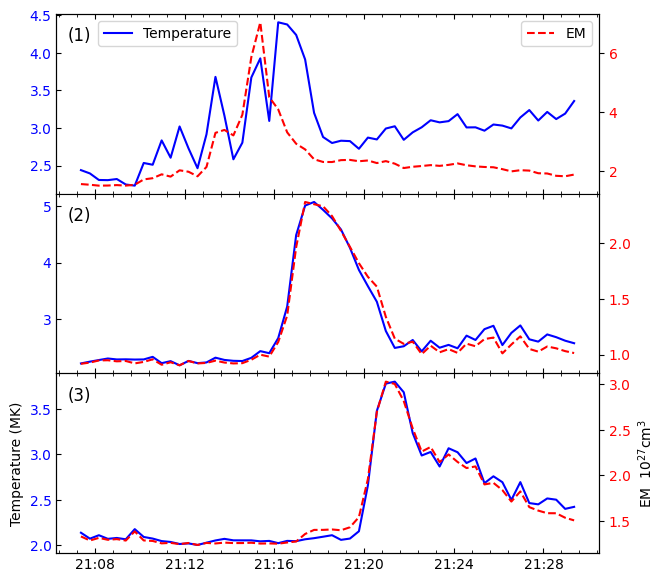

In [41]:
#ax2实际上对应avg_temp[:,0]是起点区域，时间最早所以给他放在最上面

fig,(ax2,ax1,ax3)=plt.subplots(3,1,figsize=(7,7),sharex=True,
                               gridspec_kw={'height_ratios': [1, 1, 1],'hspace': 0})

ax1.plot((avg_temp[:56,0])/1e6,label='Temperature',color='blue')
#ax1.set_ylabel('Temperature (MK)')
ax1.tick_params(axis='y',labelcolor='blue')
ax1.text(0.02,0.85,'(2)',color='black',transform=ax1.transAxes,fontsize=12)
ax11=ax1.twinx()
ax11.plot(avg_em[:56,0]/1e27,label='EM',linestyle='--',color='red')
#ax11.set_ylabel('EM  '+ r'$10^{27} \text{cm}^3$')
ax11.tick_params(axis='y',labelcolor='red')
coor_x=np.zeros(6)
for i in range(len(coor_x)):
    coor_x[i]=(i*240+38)/24
label_x=['21:08','21:12','21:16','21:20','21:24','21:28']
ax1.set_xticks(ticks=coor_x,labels=label_x)
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
ax1.yaxis.set_minor_locator(ticker.NullLocator())

ax2.plot((avg_temp[:56,1])/1e6,label='Temperature',color='blue')
#ax2.set_ylabel('Temperature (MK)')
ax2.tick_params(axis='y',labelcolor='blue')
ax2.text(0.02,0.85,'(1)',color='black',transform=ax2.transAxes,fontsize=12)

ax22=ax2.twinx()
ax22.plot(avg_em[:56,1]/1e27,label='EM',linestyle='--',color='red')
#ax22.set_ylabel('EM  '+ r'$10^{27} \text{cm}^3$')
ax22.tick_params(axis='y',labelcolor='red')
ax2.legend(loc='upper left',bbox_to_anchor=(0.065,1))
ax22.legend(loc='upper right')

ax3.plot((avg_temp[:56,2])/1e6,label='Temperature 3',color='blue')
ax3.set_ylabel('Temperature (MK)')
ax3.tick_params(axis='y',labelcolor='blue')
ax3.text(0.02,0.85,'(3)',color='black',transform=ax3.transAxes,fontsize=12)
ax33=ax3.twinx()
ax33.plot(avg_em[:56,2]/1e27,label='EM 3',linestyle='--',color='red')
ax33.set_ylabel('EM  '+ r'$10^{27} \text{cm}^3$')
ax33.tick_params(axis='y',labelcolor='red')

for ax in [ax1,ax2]:
    ax.label_outer()#去掉上两个的xlabel xticklabel
ax1.spines['top'].set_visible(False)
ax11.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax11.spines['bottom'].set_visible(False)
for ax in [ax1,ax2,ax3]:
    ax.tick_params(axis='x',which='both',direction='in',top='True')
    ax.tick_params(axis='y',which='both',direction='in')
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig2\T_DEM_time.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)


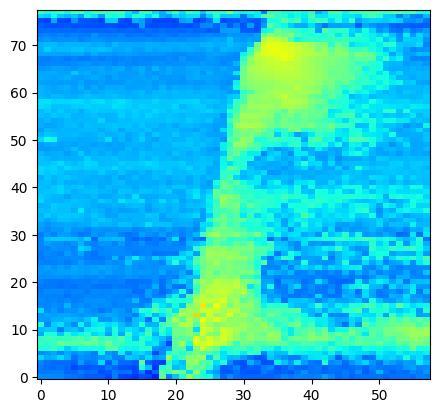

In [51]:
data_temp=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\program\temp.npy')
y_grid = np.arange(data_temp.shape[0])
x_grid = np.arange(data_temp.shape[1])
# 使用双线性插值获取 20 个时间步上的像素值
result_matrix_temp = np.zeros((78, data_temp.shape[2]))
for t in range(data_em.shape[2]):
    interp_func = RegularGridInterpolator((y_grid,x_grid), data_temp[:, :, t], method='linear')
    #这个矩阵记录的是插值点对应的值
    result_matrix_temp[:, t] = (interp_func(a)+interp_func(b)+interp_func(c))/3
plt.imshow(np.log10(result_matrix_temp),cmap='jet',origin='lower',vmin=6.0,vmax=7.3,aspect=0.7)

In [56]:
np.save(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix.npy',result_matrix_temp)

In [54]:
np.save(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix_em.npy',result_matrix_em)

5.149874071052627 4.8910559440820895 4.632244169727517
4.891058061620744
离太阳的距离是 151963569604.3406 m
一角秒对应多少千米是 736.7401757413695 km/arc
分辨率是 0.600697994 arc/pixel
尺寸是 2164.5785643123554 km/pixel
168.83712801636375
2.1645785643123556


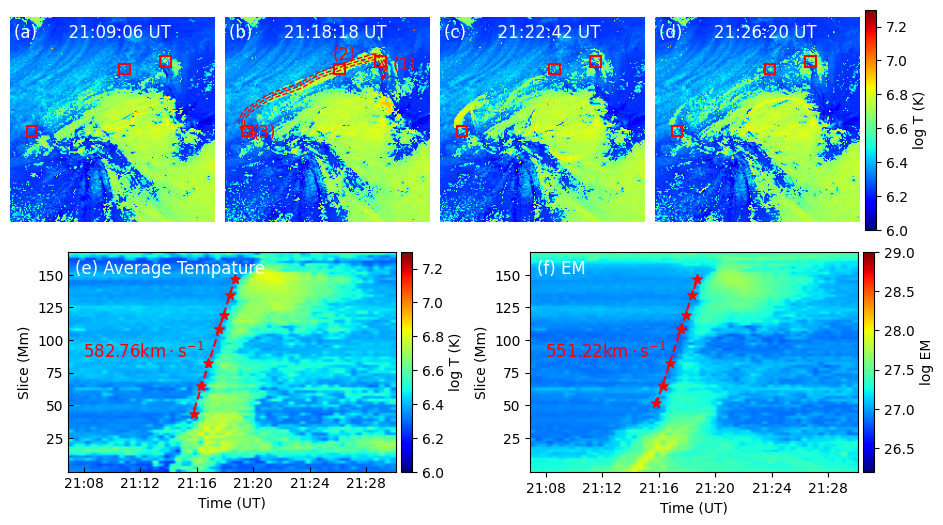

In [52]:
data=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\fit_points.npz')
slice=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix.npy')
slice_em=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix_em.npy')

a=data['fit_points']
b=data['fit_points2']
c=data['fit_points3']

#算一下距离，这里算的是平均距离，以像素为单位,时间间隔是12s*2=24s
dist1=np.average(np.sqrt(np.diff(a[:,0])**2+np.diff(a[:,1])**2))
dist2=np.average(np.sqrt(np.diff(b[:,0])**2+np.diff(b[:,1])**2))
dist3=np.average(np.sqrt(np.diff(c[:,0])**2+np.diff(c[:,1])**2))
print(dist1,dist2,dist3)
avg_diff=np.average([dist1,dist2,dist3])
print(avg_diff)

rsm=fits.open(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T210044Z.131.image_lev1.fits')
dsun_obs=rsm[1].header['DSUN_OBS']
resolution=rsm[1].header['CDELT2']
#k是一角秒对应多少千米
k=sin(np.pi/(3600*180))*dsun_obs/1000
dist=k*resolution*avg_diff
print('离太阳的距离是',dsun_obs,'m')
print('一角秒对应多少千米是',k,'km/arc')
print('分辨率是',resolution,'arc/pixel')
print('尺寸是',dist,'km/pixel')

#接下来算一下纵坐标和横坐标的值
#dist单位是km/pixel avg_dist单位是pixel,除1000变成兆米，乘78是一共多长
print(dist*1e-3*78)
trans_coeff=dist*1e-3
print(trans_coeff)
corr_y=np.zeros(6)
for i in range(len(corr_y)):
    corr_y[i]=25*(i+1)/trans_coeff
    #corr_y[i]=50*(i+1)/trans_coeff
#32是第一个点，对应时间21：07：08
#98是第三十四个点，对应时间21：20：20
#算横轴时间的对应坐标

fig=plt.figure(figsize=(12,6))
gs=gridspec.GridSpec(2,1,height_ratios=[1,1],hspace=0.1)

#图1
gs_top=gridspec.GridSpecFromSubplotSpec(1,4,subplot_spec=gs[0],wspace=0.05)
im_list=[]
ax11=fig.add_subplot(gs_top[0])
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\\'+'*.sav')
datas=readsav(file_list[10])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax11.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
im_list.append(im)
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax11.text(0.02,0.9,'(a)      21:09:06 UT',color='white',transform=ax11.transAxes,fontsize=12)
plt.gca().add_patch(rect1)
plt.axis('off')



#图2
ax22=fig.add_subplot(gs_top[1])
datas=readsav(file_list[56])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax22.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
im_list.append(im)
ax22.text(0.02,0.9,'(b)      21:18:18 UT',color='white',transform=ax22.transAxes,fontsize=12)
ax22.plot(b[:,1]/2,b[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.plot(a[:,1]/2,a[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.plot(c[:,1]/2,c[:,0]/2,linestyle='--',color='red',linewidth=1)

plt.axis('off')


#图3
ax3=fig.add_subplot(gs_top[2])
datas=readsav(file_list[78])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax3.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
ax3.text(0.02,0.9,'(c)      21:22:42 UT',color='white',transform=ax3.transAxes,fontsize=12)
im_list.append(im)
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
plt.gca().add_patch(rect1)
plt.axis('off')

#图4
ax4=fig.add_subplot(gs_top[3])
datas=readsav(file_list[96])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax4.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
im_list.append(im)
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax4.text(0.02,0.9,'(d)      21:26:20 UT',color='white',transform=ax4.transAxes,fontsize=12)
plt.gca().add_patch(rect1)
plt.axis('off')
#总的colorbar
cbar = fig.colorbar(im_list[0], ax=[ax11, ax22, ax3, ax4], 
                    orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('log T (K)')
cbar_pos = cbar.ax.get_position()
cbar.ax.set_position([cbar_pos.x0 -0.027, cbar_pos.y0, cbar_pos.width, cbar_pos.height])

ax_all=[ax11,ax22,ax3,ax4]
for i in range(4):
    left_bottom1=(102,138)
    rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
    #left_bottom2=(142,140)
    left_bottom2=(140,145)
    rect2=Rectangle(left_bottom2,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
    left_bottom3=(15,80)
    rect3=Rectangle(left_bottom3,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
    ax=ax_all[i]
    ax.add_patch(rect1)
    ax.add_patch(rect2)
    ax.add_patch(rect3)
    if i==1:
        ax.text(157,142,'(1)',color='red',fontsize=12)
        ax.text(100,152,'(2)',color='red',fontsize=12)
        ax.text(25,79,'(3)',color='red',fontsize=12)

#图5
#gs_bottom=gridspec.GridSpecFromSubplotSpec(1,2,subplot_spec=gs[1],width_ratios=[2,1],wspace=0.2,hspace=0.2)
gs_bottom=gridspec.GridSpecFromSubplotSpec(1,2,subplot_spec=gs[1]
                                            ,wspace=0.5,hspace=0.2)

corr_x=np.zeros(6)
for i in range(len(corr_x)):
    corr_x[i]=(54+i*240)/24
x_labels=['21:08','21:12','21:16','21:20','21:24','21:28']
#图5
ax5=fig.add_subplot(gs_bottom[0])
im5=ax5.imshow(np.log10(slice),cmap='jet',origin='lower',vmin=6.0,vmax=7.3,aspect=0.5)
pos5 = ax5.get_position()   # 返回 [x0, y0, width, height]
cbar5=fig.colorbar(im5, ax=ax5, orientation='vertical', fraction=0.046, pad=0.04)
cbar5.set_label('log T (K)')
#画散点和曲线
coord=[(5.8+16,20),(7+16,30),(8.2+16,38),(10.2+16,50),(11+16,55),(12.2+16,62),(13+16,68)]
x1,y1=zip(*coord)
x1,y1=np.array(x1),np.array(y1)
ax5.scatter(x=x1,y=y1,c='red',marker='*',s=50)
coeff1=np.polyfit(x1,y1,1)
poly1=np.poly1d(coeff1)
#算出来的斜率是6.46pixel_y/pixel_x*网格分辨率2164km/pixel_y
#除横轴分辨率24s/pixel_x，得到582km/s
ax5.text(2,40,'$\mathrm{582.76 km \cdot s^{-1}}$',fontsize=12,color='red')
ax5.set_yticks(ticks=corr_y,labels=['25','50','75','100','125','150'])
ax5.set_ylabel('Slice (Mm)')
ax5.set_xlabel('Time (UT)')
ax5.set_xticks(ticks=corr_x,labels=x_labels)
ax5.plot(x1,poly1(x1),c='red',linestyle='--')
ax5.tick_params(axis='both',direction='in')
ax5.text(0.02,0.9,'(e) Average Tempature',color='white',transform=ax5.transAxes,fontsize=12)
ax5.set_position([pos5.x0 + 0.03, pos5.y0, pos5.width, pos5.height])
cbar_pos = cbar5.ax.get_position()
cbar5.ax.set_position([cbar_pos.x0 +0.03, cbar_pos.y0, cbar_pos.width, cbar_pos.height])

#图6
ax6=fig.add_subplot(gs_bottom[1])
im6=ax6.imshow(np.log10(slice_em),cmap='jet',origin='lower',vmin=26.2,vmax=29,aspect=0.5)
ax6.text(0.02,0.9,'(f) EM',color='white',transform=ax6.transAxes,fontsize=12)
pos6=ax6.get_position()
cbar6=fig.colorbar(im6, ax=ax6, orientation='vertical', fraction=0.046, pad=0.04)
cbar6.set_label('log EM')
#画散点和直线
coord2=[(5.8+16,24),(7+16,30),(8.2+16,38),(10.2+16,50),(11+16,55),(12.2+16,62),(13+16,68)]
x2,y2=zip(*coord2)
x2,y2=np.array(x2),np.array(y2)
ax6.scatter(x=x2,y=y2,c='red',marker='*',s=50)
coeff2=np.polyfit(x2,y2,1)
poly2=np.poly1d(coeff2)
#算出来的斜率是6.46pixel_y/pixel_x*网格分辨率2164km/pixel_y
v2=coeff2[0]*dist/24
ax6.plot(x2,poly2(x2),c='red',linestyle='--')
ax6.text(2,40,f'{v2:.2f}'+'$\mathrm{km \cdot s^{-1}}$',fontsize=12,color='red')
#加label
ax6.set_yticks(ticks=corr_y,labels=['25','50','75','100','125','150'])
ax6.set_xticks(ticks=corr_x,labels=x_labels)
ax6.set_xlabel('Time (UT)')
ax6.set_ylabel('Slice (Mm)')
ax6.set_position([pos6.x0 - 0.05, pos6.y0, pos6.width, pos6.height])
cbar_pos = cbar6.ax.get_position()
cbar6.ax.set_position([cbar_pos.x0 -0.05, cbar_pos.y0, cbar_pos.width, cbar_pos.height])

plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig3\EM_T_time_distance.pdf',format='pdf', bbox_inches='tight')

In [66]:
data131=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131.sav')
data131_2=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\post_131.sav')
data131=data131['matrix_struct']
data131_2=data131_2['matrix_struct']
matrix_131=np.zeros((384,384,116))
for i in range(101):
    matrix=data131[i][0]
    if matrix.shape[0]!=384 or matrix.shape[1]!=384:
        matrix=zoom(matrix,(384/matrix.shape[0],384/matrix.shape[1]),order=1)
    matrix_131[:,:,i]=matrix
for i in range(15):
    matrix=data131_2[i][0]
    if matrix.shape[0]!=384 or matrix.shape[1]!=384:
        matrix=zoom(matrix,(384/matrix.shape[0],384/matrix.shape[1]),order=1)
    matrix_131[:,:,i+101]=matrix
data_131=matrix_131[:,:,0::2]
y_grid = np.arange(data_131.shape[0])
x_grid = np.arange(data_131.shape[1])
# 使用双线性插值获取 20 个时间步上的像素值
result_matrix_131 = np.zeros((78, data_131.shape[2]))
for t in range(data_131.shape[2]):
    interp_func = RegularGridInterpolator((y_grid,x_grid), data_131[:, :, t], method='linear')
    #这个矩阵记录的是插值点对应的值
    result_matrix_131[:, t] = (interp_func(a)+interp_func(b)+interp_func(c))/3

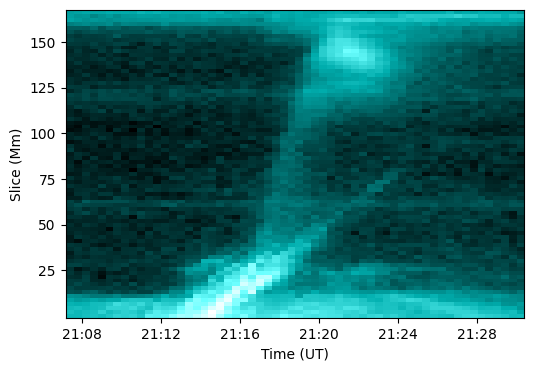

In [83]:
fig,ax=plt.subplots(figsize=(8,4))
ax.imshow(np.log10(result_matrix_131),cmap='sdoaia131',origin='lower',aspect=0.5)
ax.set_yticks(ticks=corr_y,labels=['25','50','75','100','125','150'])
#
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Slice (Mm)')
ax.set_xticks(ticks=coor_x,labels=x_labels)
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig2\131_time_distance.pdf',format='pdf', bbox_inches='tight')